In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [ ]:
with open ('../../data/raw_concat/infrastructure.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim Dim1 Value  NumericValue  \
0                AMR        NIC  NaN  0.95       0.95387   
1                AMR        CAN  NaN  2.27       2.26822   
2                WPR        IDN  NaN  0.43       0.43183   
3                WPR        FJI  NaN  0.00       0.00000   
4                AMR        CUB  NaN  2.04       2.04161   

                        Date IndicatorCode  
0  2015-03-31T09:24:16+02:00     DEVICES00  
1  2015-03-31T09:24:18+02:00     DEVICES00  
2  2015-03-31T09:24:14+02:00     DEVICES00  
3  2015-03-31T09:24:12+02:00     DEVICES00  
4  2015-03-31T09:24:18+02:00     DEVICES00  


In [14]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 170916 entries, 0 to 170915
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ParentLocationCode  164076 non-null  str    
 1   SpatialDim          170916 non-null  str    
 2   Dim1                169532 non-null  str    
 3   Value               170916 non-null  str    
 4   NumericValue        77818 non-null   float64
 5   Date                170916 non-null  str    
 6   IndicatorCode       170916 non-null  str    
dtypes: float64(1), str(6)
memory usage: 9.1 MB


,NumericValue
count,77818.000000
mean,23.687178
std,15.466027
min,0.000000
25%,8.000000
50%,26.500000
75%,36.500000
max,278.040000


In [15]:
df['NumericValue'].isnull().sum()

np.int64(93098)

In [16]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

170916
77818
0


In [17]:
# #remove indicators that not relevant
unrelated = set(['NCD_HYP_CONTROL_A', 'NCD_HYP_CONTROL_C', 'NCD_HYP_PREVALENCE_A', 'NCD_HYP_PREVALENCE_C'])
df = df[~df['IndicatorCode'].isin(unrelated)]

In [18]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['DEVICES00', 'DEVICES01', 'DEVICES03', 'DEVICES05', 'DEVICES19']


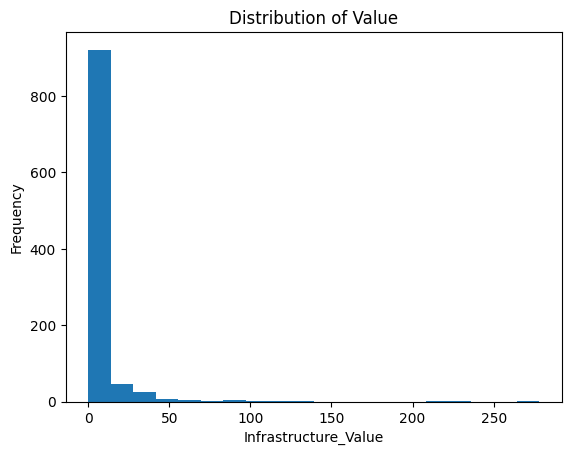

In [19]:
plt.figure()
plt.hist(df["NumericValue"], bins=20)
plt.xlabel("Infrastructure_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


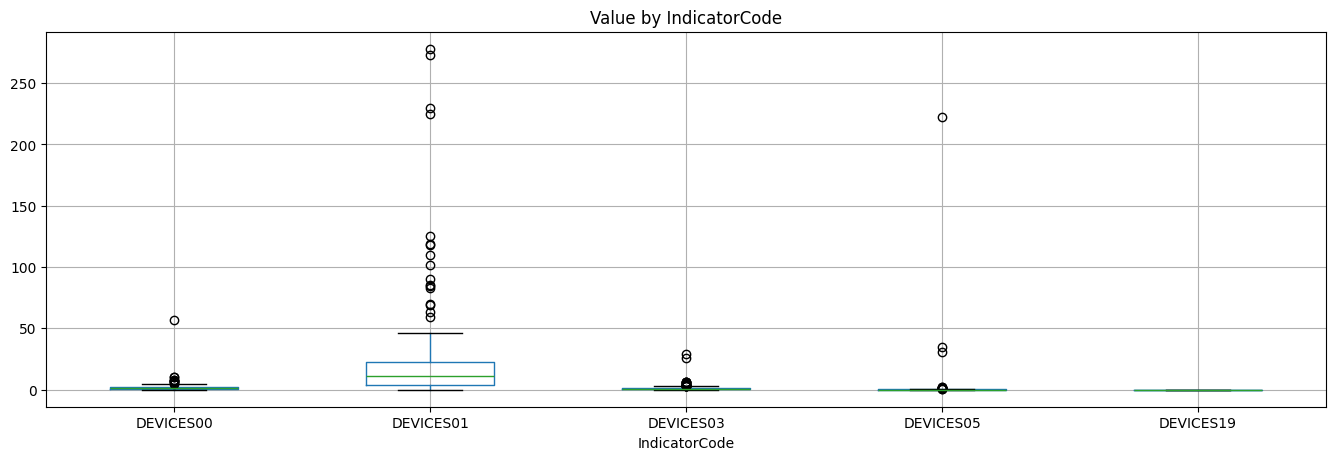

In [20]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()